<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
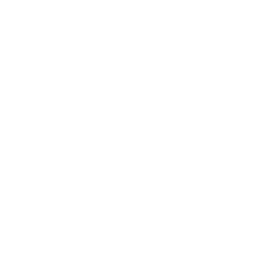
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Sairaalaosaston resurssien käyttöaste — vaakapalkkikaavio</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Terveydenhuolto / Sairaalatoiminta &nbsp;|&nbsp; maaliskuu 2026</p>
</div>
</div>
</div>

## Yhteenveto

Tässä esimerkissä käytetään **PROC GCHART** -proseduurin vaakapalkkikaavioita (HBAR) kuvaamaan työtunteja kuudella kliinisellä osastolla vuoden 2026 ensimmäisellä neljänneksellä. Synteettinen työvoimaloki, jossa on **90 vuorotietuetta** (15 per osasto), tuottaa kolme näkymää: järjestetyn kokonaistuntikaavion, osastokohtaisen keskimääräisen vuoron pituuden sekä ryhmitellyt HBAR-kaaviot, jotka jakavat kunkin osaston resurssiluokan ja vuoron mukaan. `SUMVAR=` laskee yhteen todelliset työtunnit sen sijaan, että se laskisi tietueita, `TYPE=SUM`/`TYPE=MEAN` vaihtaa vastesuureen, `DESCENDING` järjestää osastot laskevaan järjestykseen ja `GROUP=` piirtää vierekkäiset ryhmitellyt palkit toista ulottuvuutta varten.

Tuloste tukee neljännesvuosittaista toiminnan tehokkuuden katselmusta: se paljastaa, mitkä osastot kuluttavat eniten työvoimaa, millä on pisimmät vuorot ja miten päivä-/ilta-/yövuoromiehitys eroaa jatkuvan hoitoasteen yksiköiden ja päivätoimintaan keskittyvien palveluiden välillä.

## Tietolähteet

| Lähde | Kuvaus | Tietueet |
|--------|-------------|--------|
| WORK.STAFFING_LOG | Yksittäiset vuorotyötuntitietueet | 90 |
| WORK.DEPT_SUMMARY | Osastotason summat ja keskimääräinen vuoron pituus | 6 |

---

In [1]:
/* --------------------------------------------------------
   Generate a synthetic hospital staffing labor log.
   Q1 2026: 6 clinical departments, 4 resource categories,
   3 shifts. Sized to 15 shift records per department
   (90 total) so the full department roster stays visible.
   -------------------------------------------------------- */
TIEDOT work.staffing_log;
    CALL streaminit(20260601);
    PITUUS department $20 resource_type $24 shift $10;

    /* department and resource-type names are assigned via a
       direct IF/ELSE chain -- NOT a _temporary_ array -- because
       a _temporary_ char array initialized from non-ASCII string
       literals truncates values to an inconsistent shorter byte
       length regardless of the declared width. */

    /* resource-category mix (nursing-heavy clinical staffing) */
    TAULUKKO resw[4] _temporary_ (0.50 0.20 0.20 0.10);

    /* baseline shift mix, tilted toward Night for 24/7 units */
    TAULUKKO shfw[3] _temporary_ (0.45 0.30 0.25);
    TAULUKKO nightlift[6] _temporary_
        (0.18 0.00 0.22 -0.05 -0.05 0.05);

    TEE di = 1 ASTI 6;
        JOS di = 1 NIIN department = 'Päivystys';
        MUUTEN JOS di = 2 NIIN department = 'Kirurgia';
        MUUTEN JOS di = 3 NIIN department = 'Teho-osasto';
        MUUTEN JOS di = 4 NIIN department = 'Lastentaudit';
        MUUTEN JOS di = 5 NIIN department = 'Onkologia';
        MUUTEN department = 'Synnytysosasto';
        TEE rec = 1 ASTI 15;

            /* resource type via weighted draw */
            u = rand('uniform'); cum = 0;
            TEE r = 1 ASTI 4;
                cum + resw[r];
                JOS u <= cum NIIN TEE;
                    JOS r = 1 NIIN resource_type = 'Hoitotyö';
                    MUUTEN JOS r = 2 NIIN resource_type = 'Lääkäri';
                    MUUTEN JOS r = 3 NIIN resource_type = 'Asiantuntijat';
                    MUUTEN resource_type = 'Tukihenkilöstö';
                    POISTU;
                LOPPU;
            LOPPU;

            /* shift via department-specific night tilt */
            w1 = shfw[1] - nightlift[di] / 2;
            w2 = shfw[2] - nightlift[di] / 2;
            u = rand('uniform');
            JOS u <= w1 NIIN shift = 'Päivä';
            MUUTEN JOS u <= w1 + w2 NIIN shift = 'Ilta';
            MUUTEN shift = 'Yö';

            /* hours: physicians and surgery run longer shifts */
            BASE = 8;
            JOS resource_type = 'Lääkäri' NIIN BASE = BASE + 1.5;
            JOS department = 'Kirurgia'      NIIN BASE = BASE + 1.0;
            hours_worked = round(BASE + rand('normal', 0, 0.8), 0.25);
            JOS hours_worked < 4 NIIN hours_worked = 4;

            TULOSTE;
        LOPPU;
    LOPPU;
    SÄILYTÄ department resource_type shift hours_worked;
SUORITA;


NOTE: DATA work.staffing_log


NOTE: Wrote work.staffing_log (90 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.03 seconds
  cpu   0.03 seconds


In [2]:
/* --------------------------------------------------------
   Department-level totals and mean shift length,
   ranked by total labor hours.
   -------------------------------------------------------- */
PROSEDUURI SQL;
    CREATE TABLE work.dept_summary AS
    VALITSE department,
           sum(hours_worked)  AS total_hours   MUOTO=8.2,
           count(*)           AS shift_count,
           mean(hours_worked) AS avg_shift_hrs  MUOTO=6.2
    FROM work.staffing_log
    GROUP MUKAAN department
    ORDER MUKAAN total_hours DESC;
QUIT;

PROSEDUURI TULOSTA TIEDOT=work.dept_summary noobs NIMIKE;
    NIMIKE total_hours   = 'Tunnit yhteensä'
          shift_count   = 'Vuorot'
          avg_shift_hrs = 'Keskimääräinen vuoro (h)';
    OTSIKKO 'Osaston työvoimayhteenveto - Q1 2026';
SUORITA;
OTSIKKO;

                                          Osaston työvoimayhteenveto - Q1 2026                                          

    department   Tunnit yhteensä  Vuorot     Keskimääräinen vuoro (h)
Kirurgia                  136.25      15                         9.08
Teho-osasto               128.50      15                         8.57
Synnytysosasto            127.75      15                         8.52
Lastentaudit              124.75      15                         8.32
Onkologia                 123.75      15                         8.25
Päivystys                 119.25      15                         7.95




NOTE: PROC SQL 

NOTE: Table work.dept_summary created.
NOTE: PROC SQL statement used.
NOTE: PROC PRINT data=work.dept_summary

NOTE: PROC PRINT completed: 6 observations printed, 4 variables


---

                                                 Työtunnit osastoittain                                                 

                                                  The MEANS Procedure

                                            Analysis Variable : hours_worked

        department                Sum           Mean          N Obs
        -----------------------------------------------------------
        Kirurgia               136.25           9.08             15
        Lastentaudit           124.75           8.32             15
        Onkologia              123.75           8.25             15
        Päivystys              119.25           7.95             15
        Synnytysosasto         127.75           8.52             15
        Teho-osasto            128.50           8.57             15
        -----------------------------------------------------------

                                               Vuorojakauma osastoittain                                            


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_department_shift.spec.json
NOTE: PROC FREQ statement used.


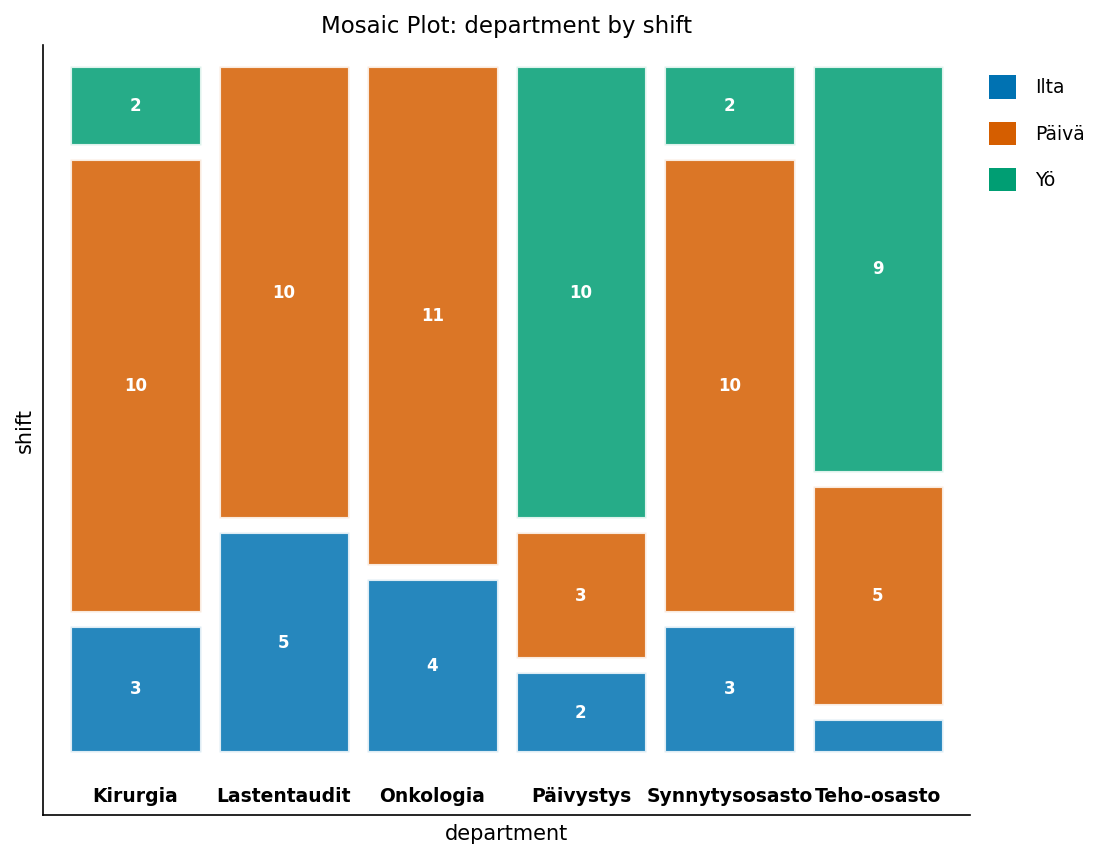

In [3]:
/* --------------------------------------------------------
   Baseline tables: labor hours by department, and the
   day / swing / night shift distribution per department.
   -------------------------------------------------------- */
PROSEDUURI KESKIARVOT TIEDOT=work.staffing_log sum mean n maxdec=2;
    LUOKKA department;
    MUUTTUJA hours_worked;
    OTSIKKO 'Työtunnit osastoittain';
SUORITA;

PROSEDUURI FREKVENSSIT TIEDOT=work.staffing_log;
    TABLES department * shift / norow nocol nopercent;
    OTSIKKO 'Vuorojakauma osastoittain';
SUORITA;
OTSIKKO;

---


NOTE: PROC GCHART data=work.staffing_log

NOTE: ODS plot written: gchart_hbar.spec.json


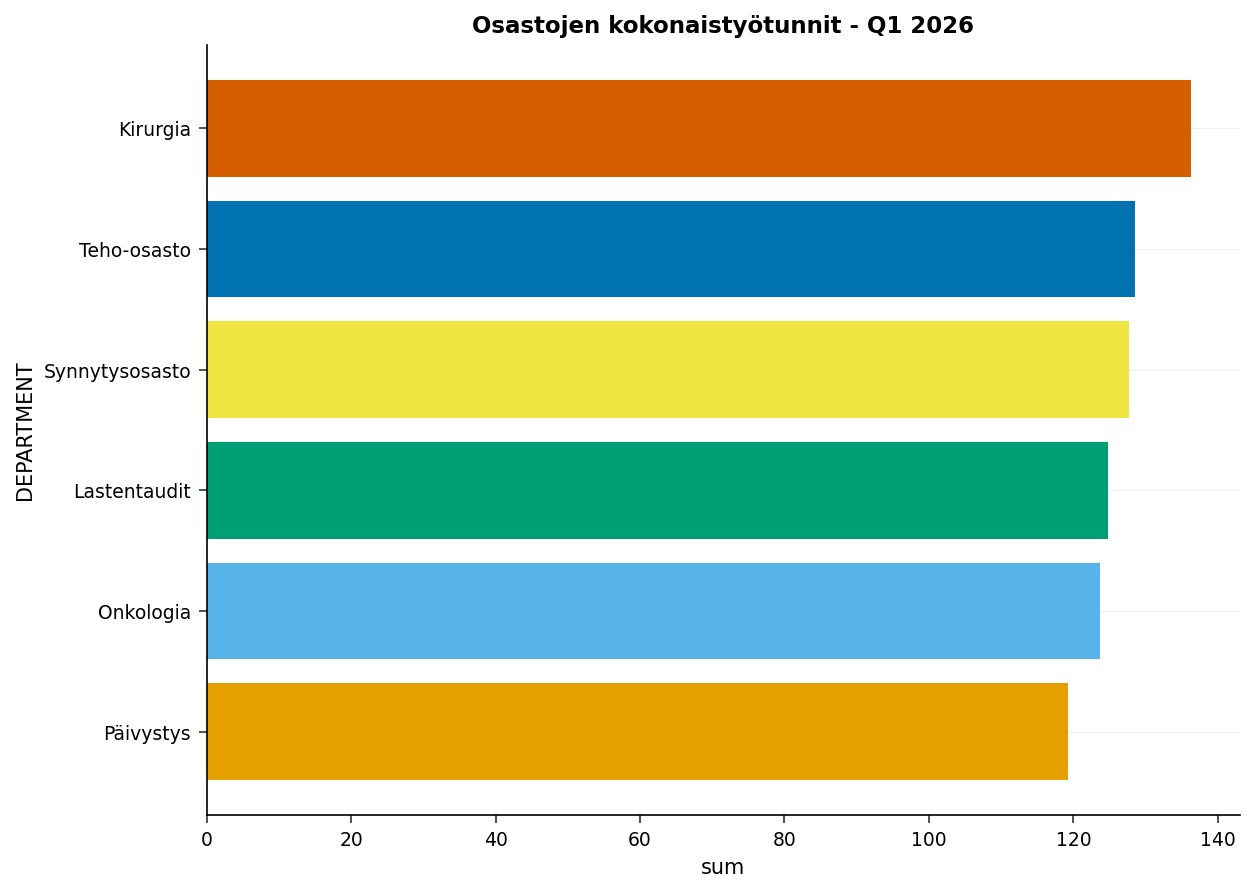

In [4]:
/* --------------------------------------------------------
   Overview HBAR: total labor hours by department.
   SUMVAR= accumulates hours; DESCENDING ranks the bars.
   -------------------------------------------------------- */
PROSEDUURI GCHART TIEDOT=work.staffing_log;
    HBAR department / SUMVAR=hours_worked
                      type=sum
                      LASKEVA;
    OTSIKKO 'Osastojen kokonaistyötunnit - Q1 2026';
SUORITA;
QUIT;
OTSIKKO;

### Osaston jakaminen resurssiluokan mukaan

`GROUP=` piirtää jokaiselle osastolle ryhmän vierekkäisiä vaakapalkkeja, yksi palkki resurssiluokkaa kohti. Koska `SUMVAR=hours_worked` on voimassa, jokainen palkki mittaa kertyneitä työtunteja tietuemäärän sijaan, joten kaavio näyttää, miten hoitotyön, lääkärin, asiantuntijoiden ja tukihenkilöstön tunnit vertautuvat toisiinsa *kunkin* osaston sisällä.

In [5]:
/* --------------------------------------------------------
   PATTERN statements: coordinated 4-color palette
   one pattern per resource type subgroup
   -------------------------------------------------------- */
pattern1 VALUE=solid color=cx2C5F8A;   /* Hoitotyö — tummansininen  */
pattern2 VALUE=solid color=cx28A745;   /* Lääkäri — vihreä          */
pattern3 VALUE=solid color=cxE8650A;   /* Asiantuntijat — keltainen */
pattern4 VALUE=solid color=cx6C757D;   /* Tukihenkilöstö — harmaa   */

                                          Osaston työtunnit resurssiluokittain                                          


Lähde: Työvoiman hallintajärjestelmä | Raportointijakso: tammi-maalis 2026



NOTE: Option TITLE changed to Osaston työtunnit resurssiluokittain.
NOTE: Option FOOTNOTE changed to Lähde: Työvoiman hallintajärjestelmä | Raportointijakso: tammi-maalis 2026.
NOTE: PROC GCHART data=work.staffing_log

NOTE: ODS plot written: gchart_hbar.spec.json


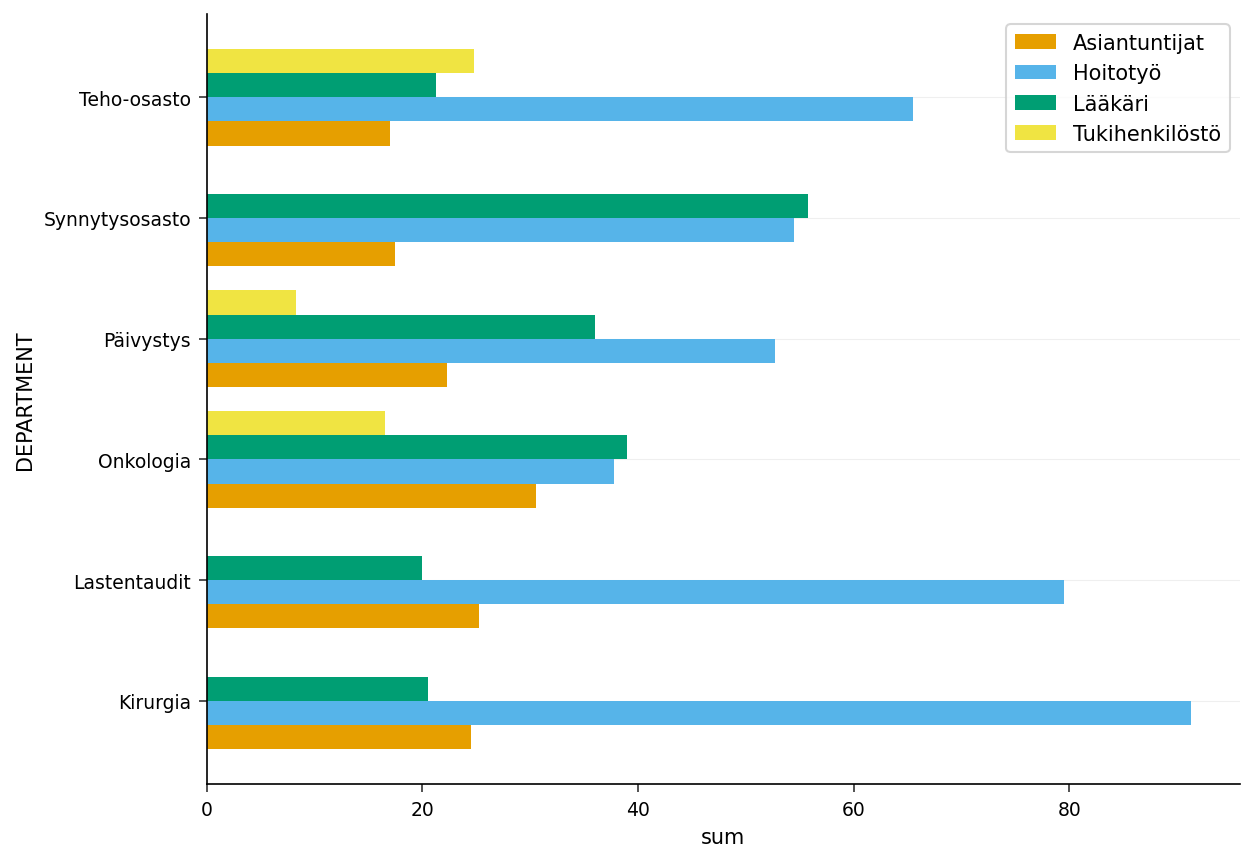

In [6]:
/* --------------------------------------------------------
   HBAR grouped by resource category (GROUP=).
   Each department becomes a cluster of bars -- one per
   resource type -- measured in accumulated labor hours.
   -------------------------------------------------------- */
OTSIKKO 'Osaston työtunnit resurssiluokittain';
footnote JUSTIFY=LEFT
    'Lähde: Työvoiman hallintajärjestelmä | Raportointijakso: tammi-maalis 2026';

PROSEDUURI GCHART TIEDOT=work.staffing_log;
    HBAR department / GROUP=resource_type
                      SUMVAR=hours_worked
                      type=sum;
SUORITA;
QUIT;

OTSIKKO; footnote;

                                              Osaston työtunnit vuorottain                                              


Ryhmitellyt palkit erottelevat päivä-, ilta- ja yövuorojen osuudet osastoittain



NOTE: Option TITLE changed to Osaston työtunnit vuorottain.
NOTE: Option FOOTNOTE changed to Ryhmitellyt palkit erottelevat päivä-, ilta- ja yövuorojen osuudet osastoittain.
NOTE: PROC GCHART data=work.staffing_log

NOTE: ODS plot written: gchart_hbar.spec.json


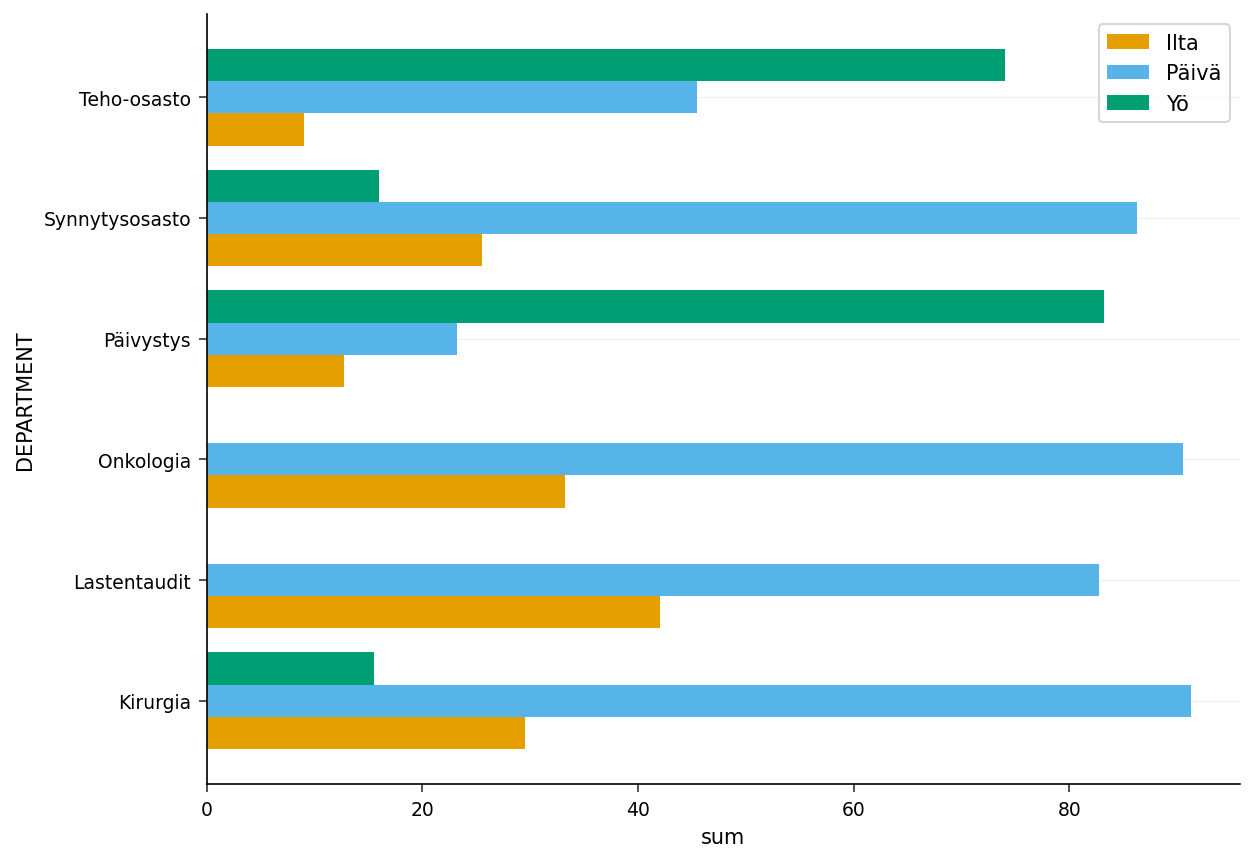

In [7]:
/* --------------------------------------------------------
   HBAR grouped by shift (GROUP=).
   Separates Day / Swing / Night labor hours within each
   department -- highlighting the 24/7 acuity units.
   -------------------------------------------------------- */
OTSIKKO 'Osaston työtunnit vuorottain';
footnote JUSTIFY=LEFT
    'Ryhmitellyt palkit erottelevat päivä-, ilta- ja yövuorojen osuudet osastoittain';

PROSEDUURI GCHART TIEDOT=work.staffing_log;
    HBAR department / GROUP=shift
                      SUMVAR=hours_worked
                      type=sum;
SUORITA;
QUIT;

OTSIKKO; footnote;


NOTE: PROC GCHART data=work.staffing_log

NOTE: ODS plot written: gchart_hbar.spec.json


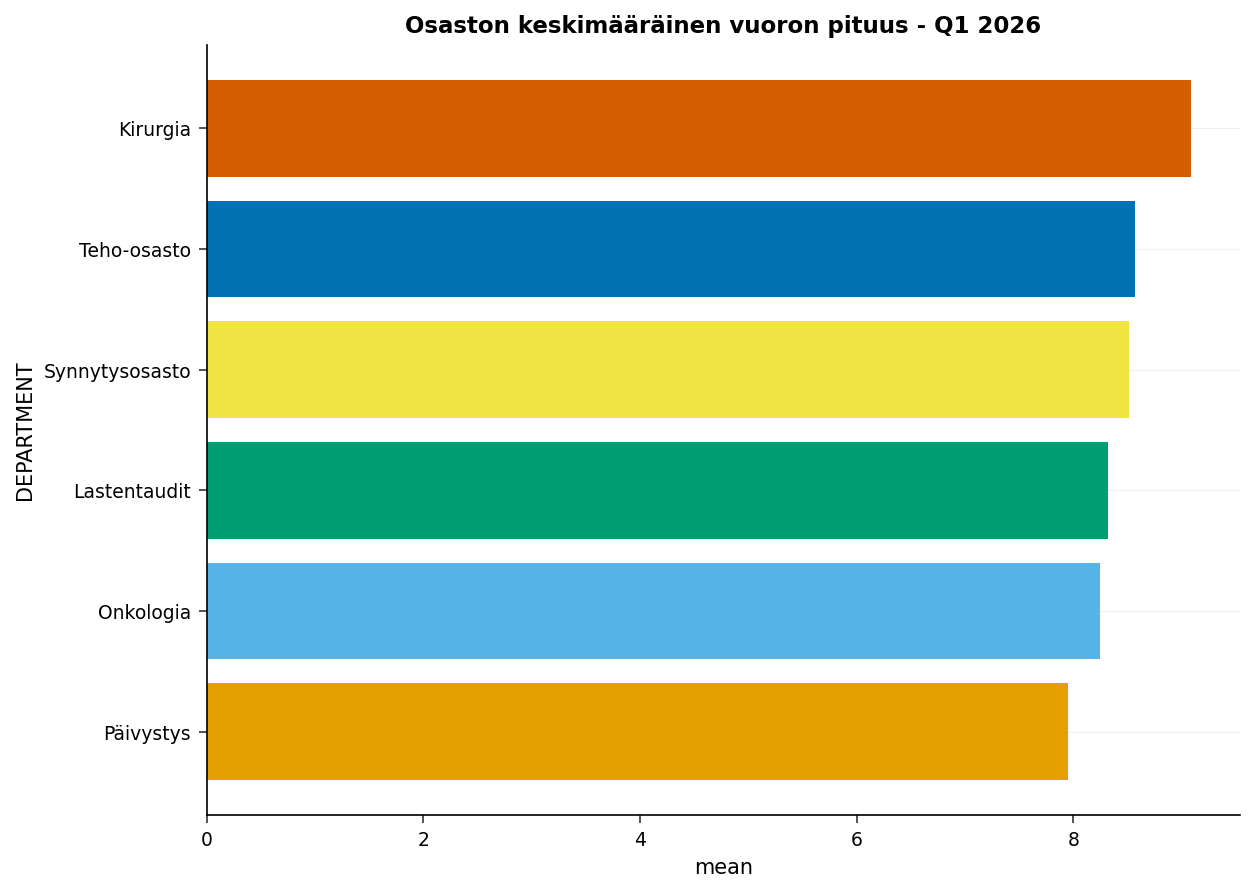

In [8]:
/* --------------------------------------------------------
   Mean shift length per department (TYPE=MEAN).
   Reveals whether a department runs long shifts or many
   shorter ones, independent of total volume.
   -------------------------------------------------------- */
PROSEDUURI GCHART TIEDOT=work.staffing_log;
    HBAR department / SUMVAR=hours_worked
                      type=mean
                      LASKEVA;
    OTSIKKO 'Osaston keskimääräinen vuoron pituus - Q1 2026';
SUORITA;
QUIT;
OTSIKKO;

---

### Tulkinta

Kaikkien 90 vuorotietueen osalta kokonaistyötunnit vaihtelevat kapealla välillä **119,25**:stä (Päivystys) **136,25**:een (Kirurgia), koska jokaisella osastolla on sama 15 vuoron määrä tällä jaksolla — joten järjestys heijastaa **vuoron pituutta**, ei vuorojen määrää. Kirurgia on ykkönen sekä kokonaistuntikaaviossa että keskimääräisen vuoron kaaviossa, **9,08 tuntia** per vuoro, mikä vastaa pidempiä leikkaustapauksia ja niiden vaatimaa lääkäripainotteista miehitystä. Päivystys on tuntien osalta viimeisenä (keskiarvo **7,95**), vaikka se on yksi kiireisimmistä yksiköistä, koska sen työ tehdään lyhyemmissä, nopeammin vaihtuvissa vuoroissa.

Vuoron mukaan ryhmitelty HBAR-kaavio ja mosaiikkipaneeli kertovat toiminnan kannalta tärkeän tarinan. **Päivystys ja teho-osasto ovat yövoittoisia** — 10/15 ja 9/15 vuoroa osuu yöhön — kun taas **Onkologia ja Lastentaudit eivät kirjaa yhtään yövuoroa** ja keskittyvät päiväaikaan (11 ja 10 päivävuoroa). Tämä jako heijastaa todellista sairaalamiehitystä: jatkuvan hoitoasteen yksiköt toimivat ympäri vuorokauden, kun taas onkologian infuusiohoito ja yleinen lastentautien hoito ovat päiväaikaisia palveluita. Resurssiluokkapaneeli vahvistaa **hoitotyövetoisen jakauman** jokaisella osastolla, ja lääkärin sekä asiantuntijoiden tunnit muodostavat toissijaiset kerrokset.

Q2-miehityskatselmusta varten yövuorojen keskittymä Päivystyksessä ja teho-osastolla on seurattava kohde: siellä kertyvät ylityölisä- ja väsymyksenhallintakustannukset, ja siellä vuorotusmuutoksilla on suurin budjettivaikutus.

---

In [9]:
/* --------------------------------------------------------
   Export the department summary for the workforce
   planning system.
   -------------------------------------------------------- */
PROSEDUURI VIE TIEDOT=work.dept_summary
    OUTFILE='q1_dept_labor_summary.csv'
    DBMS=csv REPLACE;
SUORITA;


NOTE: PROC EXPORT data=work.dept_summary outfile=q1_dept_labor_summary.csv

NOTE: Exported 6 rows to q1_dept_labor_summary.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Luottamuksellinen
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Käyttövoimana <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>